#Marketplace Funnel Analysis
*Dataset:** Olist Brazilian E-Commerce  
*Stack:* Python · pandas · SQLite · matplotlib · seaborn 
*Goal:* Analyze order funnel drop-offs, revenue patterns, and delivery performance 
across 99,441 real e-commerce orders.


In [2]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

print("Setup done")

Setup done


In [10]:
DATA_PATH = "../data/"

orders = pd.read_csv(DATA_PATH + "olist_orders_dataset.csv")
items = pd.read_csv(DATA_PATH + "olist_order_items_dataset.csv")
payments = pd.read_csv(DATA_PATH + "olist_order_payments_dataset.csv")

print("Data loaded")
print("Orders:", orders.shape)

Data loaded
Orders: (99441, 8)


In [4]:
# Remove rows where order_id is missing (just in case)
orders = orders.dropna(subset=['order_id'])

# Remove duplicates
orders = orders.drop_duplicates()

print("Basic cleaning done")

Basic cleaning done


In [5]:
# basic info 
print(orders.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB
None


In [7]:
#simple date fix
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])

print("Date fixed")

Date fixed


In [8]:
#simple useful column
orders['purchase_month'] = orders['order_purchase_timestamp'].dt.to_period('M')

print(orders[['order_purchase_timestamp', 'purchase_month']].head())

  order_purchase_timestamp purchase_month
0      2017-10-02 10:56:33        2017-10
1      2018-07-24 20:41:37        2018-07
2      2018-08-08 08:38:49        2018-08
3      2017-11-18 19:28:06        2017-11
4      2018-02-13 21:18:39        2018-02


In [9]:
####### MAIN PART ####
#FUNNEL
total_orders = len(orders)
print("Total orders:",total_orders)

Total orders: 99441


In [11]:
#order with items
orders_with_items = len(items['order_id'].unique())
print("Orders with Items:", orders_with_items)


Orders with Items: 98666


In [12]:
#orders with payment
orders_with_payment = len(payments['order_id'].unique())
print("Orders with Payment:", orders_with_payment)

Orders with Payment: 99440


In [13]:
#delivered orders
delivered_orders = len(orders[orders['order_status'] == 'delivered'])
print("Delivered Orders:", delivered_orders)

Delivered Orders: 96478


In [14]:
#conversion rate
print("Delivery Rate:", delivered_orders / total_orders)
print("Payment Success Rate:", orders_with_payment / total_orders)

Delivery Rate: 0.9702034372140264
Payment Success Rate: 0.9999899437857624


In [15]:
import sqlite3

# Create database (file will be created automatically)
conn = sqlite3.connect("ecommerce.db")

# Save tables to SQL
orders.to_sql("orders", conn, if_exists="replace", index=False)
items.to_sql("items", conn, if_exists="replace", index=False)
payments.to_sql("payments", conn, if_exists="replace", index=False)

print("Data moved to SQL ✓")

Data moved to SQL ✓


In [16]:
query = """
SELECT COUNT(DISTINCT order_id) as total_orders
FROM orders
"""

result = pd.read_sql(query, conn)
print(result)

   total_orders
0         99441


In [17]:
#funnel using sql
query = """
SELECT 
    (SELECT COUNT(DISTINCT order_id) FROM orders) as total_orders,
    (SELECT COUNT(DISTINCT order_id) FROM items) as orders_with_items,
    (SELECT COUNT(DISTINCT order_id) FROM payments) as orders_with_payment,
    (SELECT COUNT(DISTINCT order_id) FROM orders WHERE order_status='delivered') as delivered_orders
"""

funnel = pd.read_sql(query, conn)
print(funnel)

   total_orders  orders_with_items  orders_with_payment  delivered_orders
0         99441              98666                99440             96478


#SQL ANALYSIS

In [1]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("ecommerce.db")
print("Connected ✓")

Connected ✓


In [2]:
funnel = pd.read_sql("""
    SELECT 
        order_status,
        COUNT(*) as total_orders,
        ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM orders), 2) as percentage
    FROM orders
    GROUP BY order_status
    ORDER BY total_orders DESC
""", conn)

print(funnel)

  order_status  total_orders  percentage
0    delivered         96478       97.02
1      shipped          1107        1.11
2     canceled           625        0.63
3  unavailable           609        0.61
4     invoiced           314        0.32
5   processing           301        0.30
6      created             5        0.01
7     approved             2        0.00


In [3]:
dropoff = pd.read_sql("""
    SELECT
        COUNT(*) as total_created,
        SUM(CASE WHEN order_status != 'canceled' THEN 1 ELSE 0 END) as approved,
        SUM(CASE WHEN order_status IN ('shipped','delivered') THEN 1 ELSE 0 END) as shipped,
        SUM(CASE WHEN order_status = 'delivered' THEN 1 ELSE 0 END) as delivered
    FROM orders
""", conn)

print(dropoff)

   total_created  approved  shipped  delivered
0          99441     98816    97585      96478


In [4]:
monthly = pd.read_sql("""
    SELECT 
        STRFTIME('%Y-%m', order_purchase_timestamp) as month,
        COUNT(*) as total_orders
    FROM orders
    WHERE order_purchase_timestamp IS NOT NULL
    GROUP BY month
    ORDER BY month
""", conn)

print(monthly)

      month  total_orders
0   2016-09             4
1   2016-10           324
2   2016-12             1
3   2017-01           800
4   2017-02          1780
5   2017-03          2682
6   2017-04          2404
7   2017-05          3700
8   2017-06          3245
9   2017-07          4026
10  2017-08          4331
11  2017-09          4285
12  2017-10          4631
13  2017-11          7544
14  2017-12          5673
15  2018-01          7269
16  2018-02          6728
17  2018-03          7211
18  2018-04          6939
19  2018-05          6873
20  2018-06          6167
21  2018-07          6292
22  2018-08          6512
23  2018-09            16
24  2018-10             4


In [5]:
revenue = pd.read_sql("""
    SELECT 
        payment_type,
        COUNT(*) as transactions,
        ROUND(SUM(payment_value), 2) as total_revenue,
        ROUND(AVG(payment_value), 2) as avg_order_value
    FROM payments
    GROUP BY payment_type
    ORDER BY total_revenue DESC
""", conn)

print(revenue)

  payment_type  transactions  total_revenue  avg_order_value
0  credit_card         76795    12542084.19           163.32
1       boleto         19784     2869361.27           145.03
2      voucher          5775      379436.87            65.70
3   debit_card          1529      217989.79           142.57
4  not_defined             3           0.00             0.00


In [6]:
top_items = pd.read_sql("""
    SELECT 
        product_id,
        COUNT(*) as times_ordered,
        ROUND(SUM(price), 2) as total_revenue,
        ROUND(AVG(price), 2) as avg_price
    FROM items
    GROUP BY product_id
    ORDER BY times_ordered DESC
    LIMIT 10
""", conn)

print(top_items)

                         product_id  times_ordered  total_revenue  avg_price
0  aca2eb7d00ea1a7b8ebd4e68314663af            527       37608.90      71.36
1  99a4788cb24856965c36a24e339b6058            488       43025.56      88.17
2  422879e10f46682990de24d770e7f83d            484       26577.22      54.91
3  389d119b48cf3043d311335e499d9c6b            392       21440.59      54.70
4  368c6c730842d78016ad823897a372db            388       21056.80      54.27
5  53759a2ecddad2bb87a079a1f1519f73            373       20387.20      54.66
6  d1c427060a0f73f6b889a5c7c61f2ac4            343       47214.51     137.65
7  53b36df67ebb7c41585e8d54d6772e08            323       37683.42     116.67
8  154e7e31ebfa092203795c972e5804a6            281        6325.19      22.51
9  3dd2a17168ec895c781a9191c1e95ad7            274       41082.60     149.94


In [7]:
delivery = pd.read_sql("""
    SELECT
        ROUND(AVG(
            JULIANDAY(order_delivered_customer_date) - 
            JULIANDAY(order_purchase_timestamp)
        ), 1) as avg_delivery_days,
        MIN(
            JULIANDAY(order_delivered_customer_date) - 
            JULIANDAY(order_purchase_timestamp)
        ) as min_days,
        MAX(
            JULIANDAY(order_delivered_customer_date) - 
            JULIANDAY(order_purchase_timestamp)
        ) as max_days
    FROM orders
    WHERE order_delivered_customer_date IS NOT NULL
""", conn)

print(delivery)

   avg_delivery_days  min_days    max_days
0               12.6  0.533414  209.628611


#VISUALIZATION

#IMPORT


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs("../outputs", exist_ok=True)
sns.set_theme(style="whitegrid")

#FUNNEL CHART

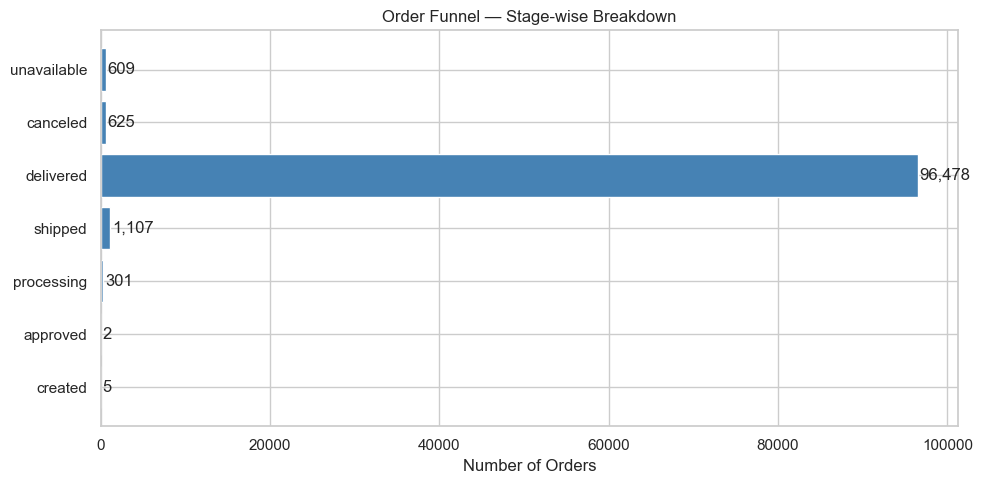

In [9]:
funnel_order = ['created', 'approved', 'processing', 'shipped', 'delivered', 'canceled', 'unavailable']
funnel_filtered = funnel[funnel['order_status'].isin(funnel_order)].copy()
funnel_filtered['order_status'] = pd.Categorical(funnel_filtered['order_status'], categories=funnel_order, ordered=True)
funnel_filtered = funnel_filtered.sort_values('order_status')

plt.figure(figsize=(10, 5))
bars = plt.barh(funnel_filtered['order_status'], funnel_filtered['total_orders'], color='steelblue')
plt.xlabel("Number of Orders")
plt.title("Order Funnel — Stage-wise Breakdown")
for bar, val in zip(bars, funnel_filtered['total_orders']):
    plt.text(bar.get_width() + 200, bar.get_y() + bar.get_height()/2, f'{val:,}', va='center')
plt.tight_layout()
plt.savefig("../outputs/funnel_chart.png", dpi=150)
plt.show()

#MONTLY ORDER TREND

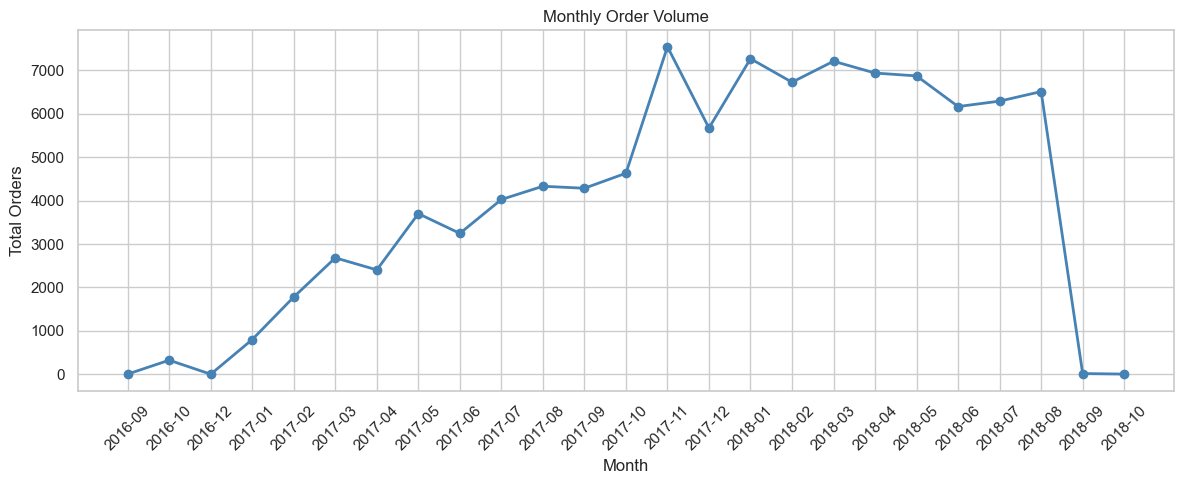

In [10]:
plt.figure(figsize=(12, 5))
plt.plot(monthly['month'], monthly['total_orders'], marker='o', color='steelblue', linewidth=2)
plt.xticks(rotation=45)
plt.title("Monthly Order Volume")
plt.xlabel("Month")
plt.ylabel("Total Orders")
plt.tight_layout()
plt.savefig("../outputs/monthly_trend.png", dpi=150)
plt.show()

#REVENUE BY PAYMENT TYPE

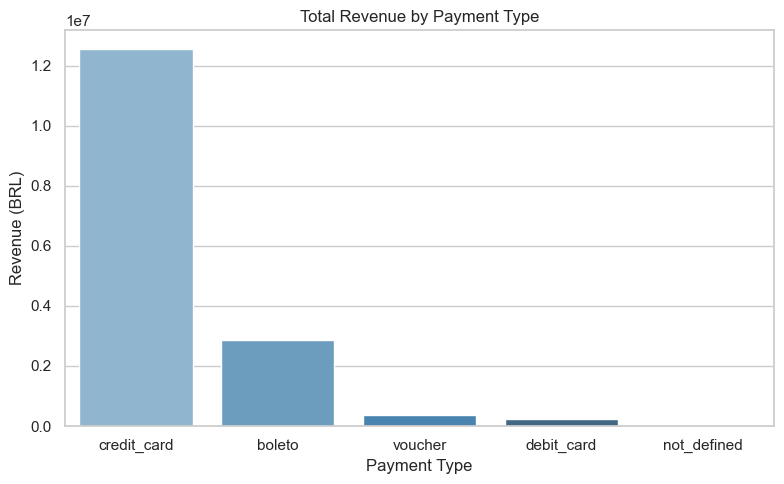

In [15]:
plt.figure(figsize=(8, 5))
sns.barplot(data=revenue, x='payment_type', y='total_revenue', 
            hue='payment_type', palette='Blues_d', legend=False)
plt.title("Total Revenue by Payment Type")
plt.xlabel("Payment Type")
plt.ylabel("Revenue (BRL)")
plt.tight_layout()
plt.savefig("../outputs/revenue_by_payment.png", dpi=150)
plt.show()

#DELIVERY TIME DISTRUBUTION


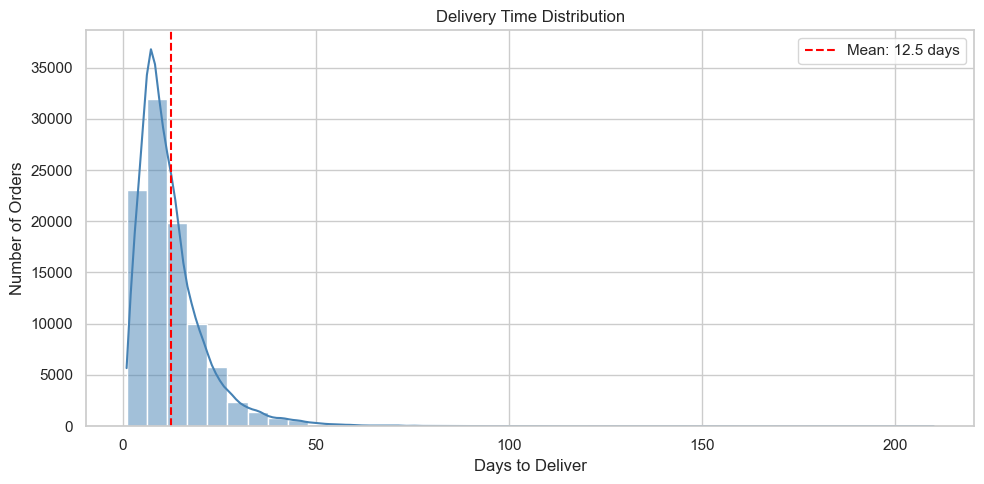

In [12]:
delivered_orders = pd.read_sql("""
    SELECT 
        ROUND(JULIANDAY(order_delivered_customer_date) - 
              JULIANDAY(order_purchase_timestamp), 0) as delivery_days
    FROM orders
    WHERE order_delivered_customer_date IS NOT NULL
    AND order_status = 'delivered'
""", conn)

plt.figure(figsize=(10, 5))
sns.histplot(delivered_orders['delivery_days'], bins=40, color='steelblue', kde=True)
plt.axvline(delivered_orders['delivery_days'].mean(), color='red', linestyle='--', label=f"Mean: {delivered_orders['delivery_days'].mean():.1f} days")
plt.title("Delivery Time Distribution")
plt.xlabel("Days to Deliver")
plt.ylabel("Number of Orders")
plt.legend()
plt.tight_layout()
plt.savefig("../outputs/delivery_distribution.png", dpi=150)
plt.show()

#ORDER HEATMAP (HOURS VS DAY OF WEEK)

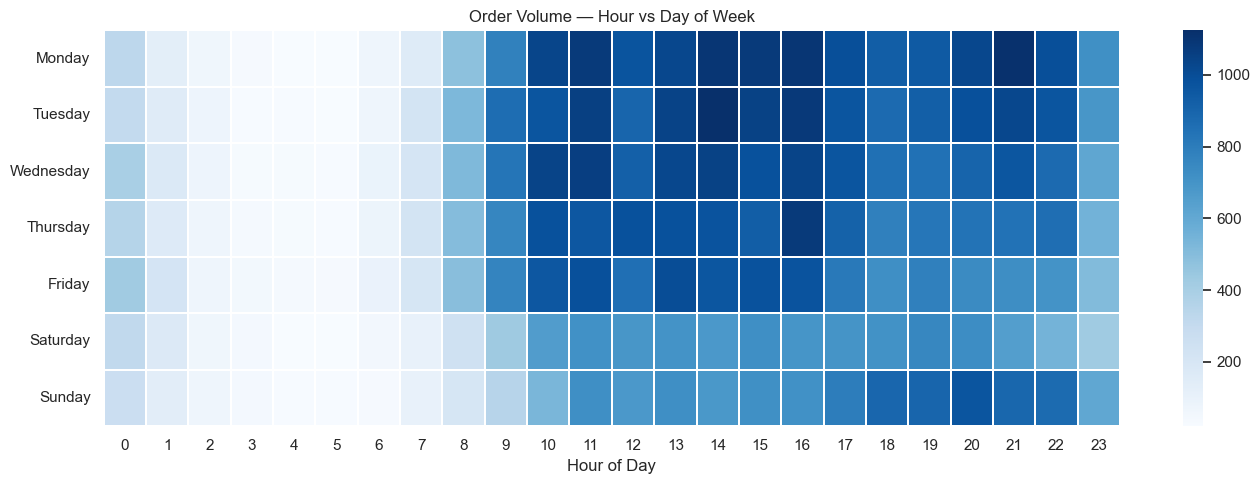

In [13]:
orders_df = pd.read_sql("""
    SELECT order_purchase_timestamp FROM orders
    WHERE order_purchase_timestamp IS NOT NULL
""", conn)

orders_df['order_purchase_timestamp'] = pd.to_datetime(orders_df['order_purchase_timestamp'])
orders_df['hour'] = orders_df['order_purchase_timestamp'].dt.hour
orders_df['day'] = orders_df['order_purchase_timestamp'].dt.day_name()

day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
heatmap_data = orders_df.groupby(['day','hour']).size().unstack(fill_value=0)
heatmap_data = heatmap_data.reindex(day_order)

plt.figure(figsize=(14, 5))
sns.heatmap(heatmap_data, cmap='Blues', linewidths=0.3)
plt.title("Order Volume — Hour vs Day of Week")
plt.xlabel("Hour of Day")
plt.ylabel("")
plt.tight_layout()
plt.savefig("../outputs/orders_heatmap.png", dpi=150)
plt.show()

In [16]:
conn = sqlite3.connect("ecommerce.db")

total_orders = pd.read_sql("SELECT COUNT(*) as count FROM orders", conn).iloc[0,0]
with_items = pd.read_sql("SELECT COUNT(DISTINCT order_id) as count FROM items", conn).iloc[0,0]
with_payment = pd.read_sql("SELECT COUNT(DISTINCT order_id) as count FROM payments", conn).iloc[0,0]
delivered = pd.read_sql("SELECT COUNT(*) as count FROM orders WHERE order_status='delivered'", conn).iloc[0,0]
canceled = pd.read_sql("SELECT COUNT(*) as count FROM orders WHERE order_status='canceled'", conn).iloc[0,0]

print(f"Total Orders     : {total_orders:,}")
print(f"Orders with Items: {with_items:,}")
print(f"Orders with Pay  : {with_payment:,}")
print(f"Delivered        : {delivered:,}")
print(f"Canceled         : {canceled:,}")
print(f"\nItem conversion     : {with_items/total_orders*100:.1f}%")
print(f"Payment conversion  : {with_payment/total_orders*100:.1f}%")
print(f"Delivery conversion : {delivered/total_orders*100:.1f}%")
print(f"Cancellation rate   : {canceled/total_orders*100:.1f}%")

Total Orders     : 99,441
Orders with Items: 98,666
Orders with Pay  : 99,440
Delivered        : 96,478
Canceled         : 625

Item conversion     : 99.2%
Payment conversion  : 100.0%
Delivery conversion : 97.0%
Cancellation rate   : 0.6%


In [17]:
pay_summary = pd.read_sql("""
    SELECT payment_type,
           COUNT(*) as transactions,
           ROUND(SUM(payment_value),2) as total_revenue,
           ROUND(AVG(payment_value),2) as avg_value
    FROM payments
    GROUP BY payment_type
    ORDER BY total_revenue DESC
""", conn)

print(pay_summary)
conn.close()

  payment_type  transactions  total_revenue  avg_value
0  credit_card         76795    12542084.19     163.32
1       boleto         19784     2869361.27     145.03
2      voucher          5775      379436.87      65.70
3   debit_card          1529      217989.79     142.57
4  not_defined             3           0.00       0.00


#CLOSE DB CONNECTION

In [18]:
conn.close()
print("Notebook complete. All charts saved to outputs/ ✓")

Notebook complete. All charts saved to outputs/ ✓


### Buiseness Insights

### Insight 1 
### Strong Fulfillment Efficiency
Approximately 97% of orders are successfully delivered, with a very low cancellation rate (~0.6%).
This indicates a highly efficient logistics and fulfillment system with minimal drop-offs after purchase.


### Insight 2 

### High Payment completion rate

Nearly all initiated orders successfully reach the payment stage, suggesting a smooth and reliable checkout experience.
Payment abandonment is minimal, reflecting strong user trust and platform usability.

### Insight 3

### Revenue concentration in credit cards

Credit cards contribute ~77% of total revenue (BRL 12.5M), making them the dominant payment method.
This creates a dependency risk, where any disruption in card processing could significantly impact revenue.

### Insight 4

### Limited contribution from alternate payments

Payment methods like Boleto contribute significantly less (BRL 2.9M) compared to credit cards.
This suggests an opportunity to diversify payment adoption and reduce reliance on a single channel.

### Insight 5 

###  voucher users show lower spending behaviour

Voucher-based transactions have an average order value of BRL 65.70, significantly lower than credit card (BRL 163.32) and boleto (BRL 145.03).
This indicates voucher users are likely price-sensitive or discount-driven.
A potential strategy is to introduce minimum cart thresholds for voucher usage to increase revenue per order.

### Insight 6

### Minor conversion leak in order creation

A gap of 775 orders (99,441 total vs 98,666 with items) indicates incomplete transactions.
These may represent cart abandonment or system-level issues, highlighting a small but actionable conversion loss.

### Insight 7

### Delivery Time Variability and outliers

The average delivery time is ~12.6 days, which is reasonable; however, extreme cases go up to 209 days.
These outliers suggest operational inefficiencies or edge-case failures, which could negatively impact customer satisfaction.
Addressing these anomalies can improve retention and trust.

### Insight 8 

### funnel optimization opportunity

Although overall conversion is high, small drop-offs across stages still exist.
Even marginal improvements in these areas can lead to scalable revenue gains and better user experience.